# Classifier Analysis

## 1) Setup

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data
from src.train.config_setup import load_and_prepare_model
from src.utils.mask_utils import get_non_pad_mask
from src.utils.metrics import classification_metrics
from src.utils.utils import _to_np_datetime64_seconds, set_seed
import src.data.event_loader as loader
import src.utils.viz_analysis as analysis
import src.utils.interpretability as interp

set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
NOTEBOOK_NAME = 'classifier_analysis'
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
FIG_BATCH_DIR = FIG_DIR / 'batch'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_BATCH_DIR.mkdir(parents=True, exist_ok=True)

data_start = [1970, 1, 1, 0, 0, 0]
t0_np = _to_np_datetime64_seconds(datetime(*data_start))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Load Checkpoint and Data

In [2]:
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments/clf_grid_r_2/runs/tf_60_mf_5p0_seed_2'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'
USE_TORCH_COMPILE = False
BATCH_SIZE = 32


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
args.use_sampler = False
args.batch_size = BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=str(base_dir), args=args)
data_loader = loader.get_dataloader(
    catalog_ds,
    batch_size=args.batch_size,
    shuffle=False,
    task_type=args.task_type,
)

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset}')

Loaded checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_grid_r_2/runs/tf_60_mf_5p0_seed_2/best_model_1.pth
Dataset: ChuanDian


## 3) Representation Probe

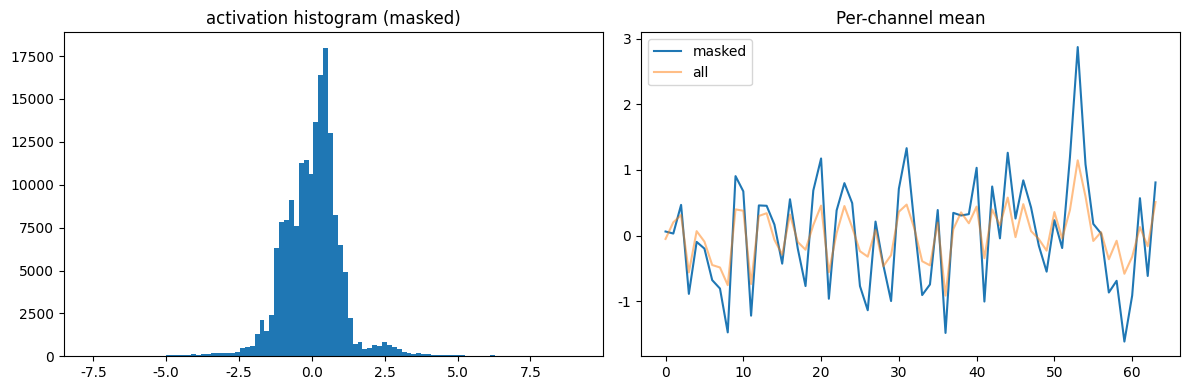

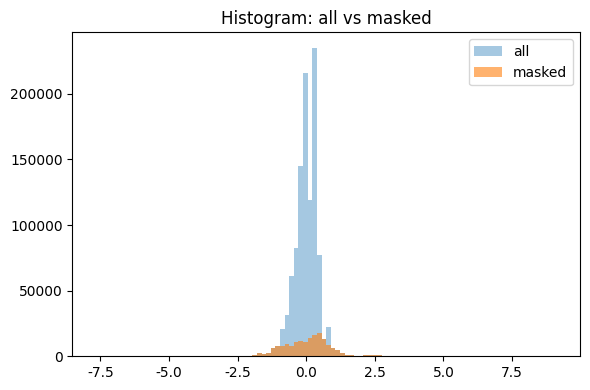

In [3]:
x_batch, y_batch = next(iter(data_loader))
x_batch = x_batch.to(DEVICE)
y_batch = y_batch.to(DEVICE)

valid_mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().bool()
_activations = interp.capture_layer_activations(
    model,
    x_batch,
    module=model.base_model.encoder.layers[0],
    valid_mask=valid_mask,
    visualize=True,
)

## 4) Model Metrics and t-SNE by Split

=== TRAIN: classification_metrics ===
{'precision': 0.6964504283965728, 'recall': 0.8454680534918276, 'f1': 0.763758389261745, 'auc': 0.7931387647310069, 'pr_auc': 0.868136815920519, 'fpr': 0.5020242914979757, 'tpr': 0.8454680534918276, 'R': 0.34344376199385196, 'conf': 1.0, 'threshold': 0.47874149680137634}


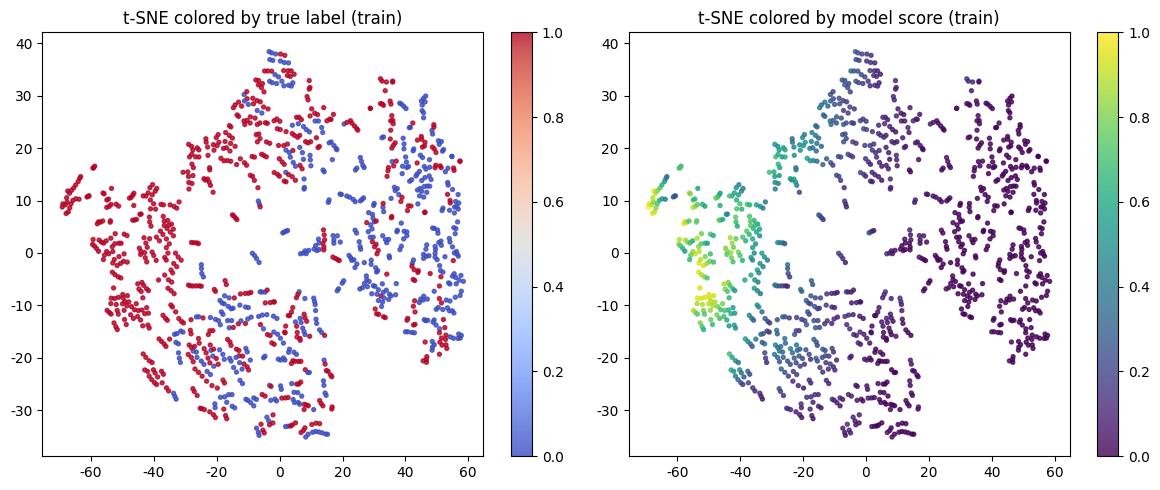

=== VAL: classification_metrics ===
{'precision': 0.6041666666666666, 'recall': 1.0, 'f1': 0.7532467532467533, 'auc': 0.6956004756242569, 'pr_auc': 0.8404849437250883, 'fpr': 0.9827586206896551, 'tpr': 1.0, 'R': 0.017241379310344862, 'conf': 1.9325004024455881e-62, 'threshold': 0.46851158142089844}


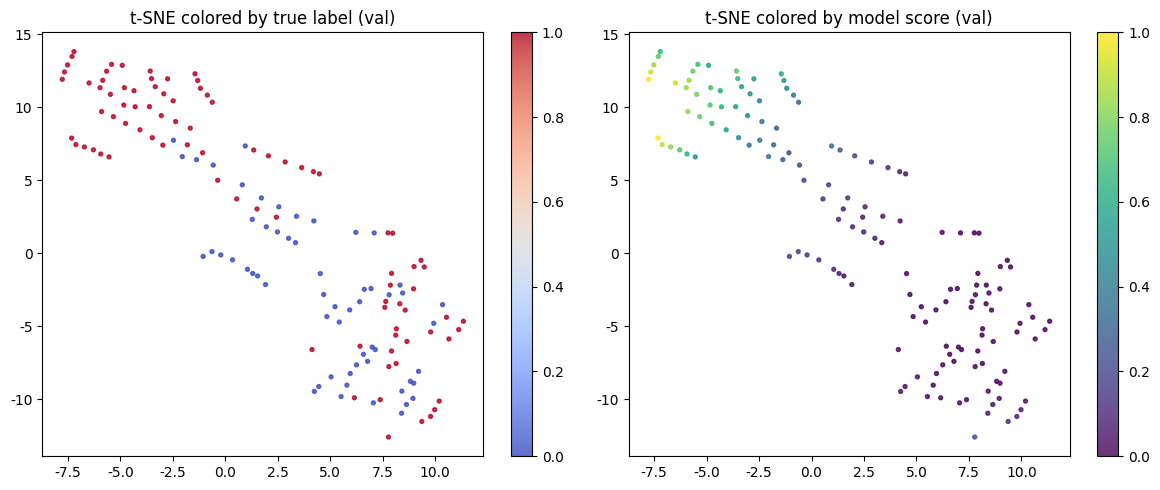

=== TEST: classification_metrics ===
{'precision': 0.703125, 'recall': 0.9375, 'f1': 0.8035714285714286, 'auc': 0.9122474747474747, 'pr_auc': 0.8793188184913022, 'fpr': 0.1919191919191919, 'tpr': 0.9375, 'R': 0.7455808080808081, 'conf': 1.0, 'threshold': 0.478342205286026}


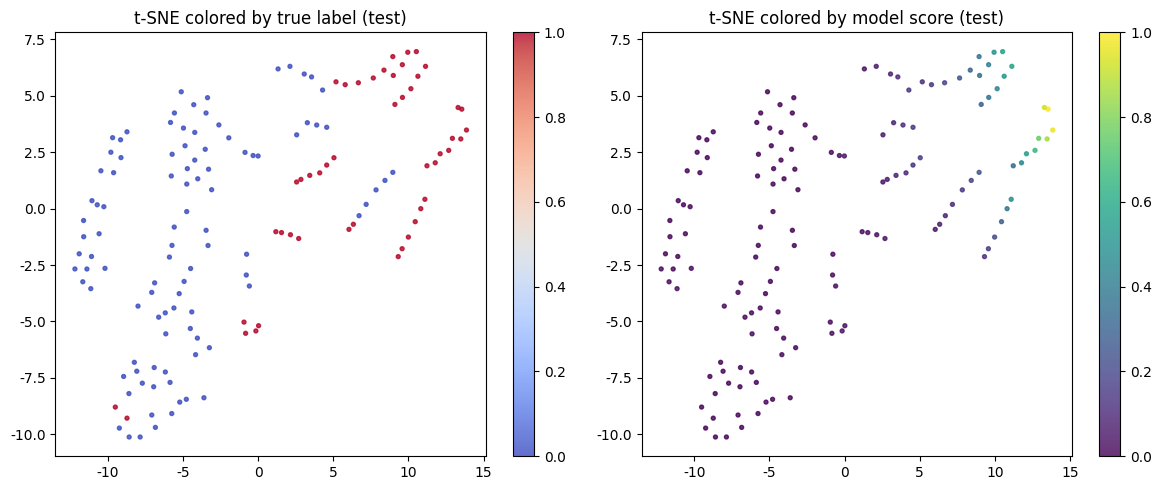

In [4]:
split_outputs = {
    'train': analysis.predict_all(model, train_loader, DEVICE, return_X=True),
    'val': analysis.predict_all(model, val_loader, DEVICE, return_X=True),
    'test': analysis.predict_all(model, test_loader, DEVICE, return_X=True),
}


def run_metrics_and_tsne(split_outputs: dict, splits=('val',), do_tsne: bool = True):
    for split in splits:
        if split not in split_outputs:
            print(f'[Skip] Unknown split: {split}')
            continue

        y_pred, y_true, x_feat = split_outputs[split]

        print(f'=== {split.upper()}: classification_metrics ===')
        try:
            print(classification_metrics(y_true, y_pred))
        except Exception as exc:
            print(f'[Warn] classification_metrics({split}) failed: {exc}')

        if do_tsne:
            try:
                analysis.tsne_scatter(
                    x_feat.astype(float),
                    y_all=y_true,
                    y_pred_all=y_pred,
                    title_left=f't-SNE colored by true label ({split})',
                    title_right=f't-SNE colored by model score ({split})',
                )
            except Exception as exc:
                print(f'[Warn] t-SNE({split}) failed: {exc}')


selected_splits = ['train', 'val', 'test']
run_metrics_and_tsne(split_outputs, splits=selected_splits, do_tsne=True)

## 5) Random Forest Baseline on Learned Features

Accuracy: 0.8231292517006803
              precision    recall  f1-score   support

         0.0     0.8544    0.8889    0.8713        99
         1.0     0.7500    0.6875    0.7174        48

    accuracy                         0.8231       147
   macro avg     0.8022    0.7882    0.7943       147
weighted avg     0.8203    0.8231    0.8210       147

ROC AUC: 0.8371212121212122


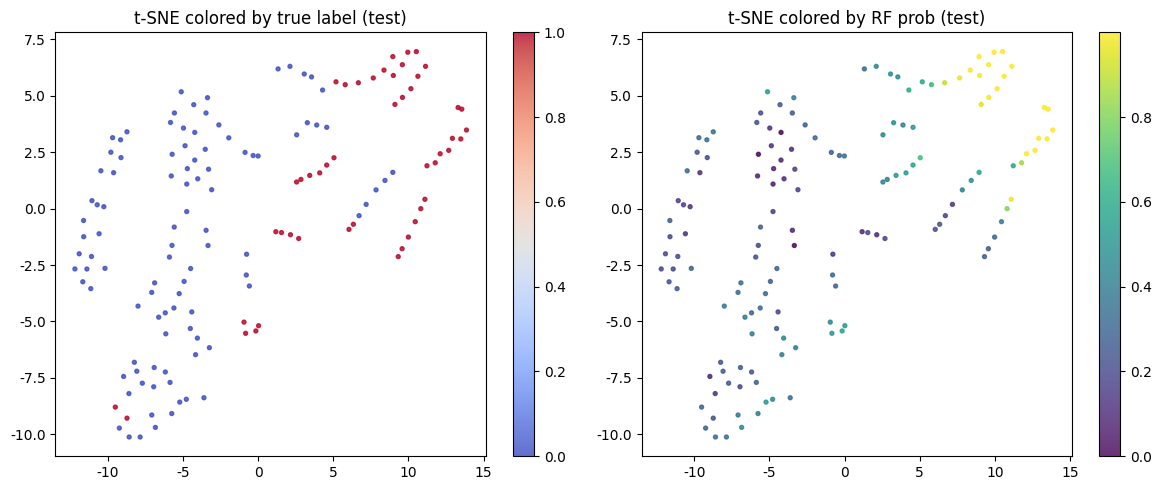

(array([[ 0.24486142,  0.28219955,  0.74870093, ...,  0.30163594,
          0.89665994,  0.17205029],
        [-0.17703967, -0.157309  ,  1.0972093 , ...,  0.42914368,
          0.5423337 ,  0.35462708],
        [-0.52683075, -0.64072493,  1.28416532, ...,  0.43520196,
          0.35499468,  0.47174952],
        ...,
        [-0.68299205, -0.84405356, -0.32381545, ...,  0.84487609,
         -1.13796098,  0.98936639],
        [-0.75818034, -0.87222907, -0.14803083, ...,  0.85508544,
         -1.13857766,  0.95944969],
        [-0.84979368, -0.92803414, -0.01266787, ...,  0.95288315,
         -1.25465708,  0.97567242]]),
 array([[ 4.55746746e+00,  3.60575581e+00],
        [ 3.88979316e+00,  3.70590806e+00],
        [ 3.26634622e+00,  3.80877709e+00],
        [ 2.55622840e+00,  3.27131724e+00],
        [-1.24287484e-02,  2.33374262e+00],
        [-3.43956828e-01,  2.35349965e+00],
        [-8.81578565e-01,  2.49341297e+00],
        [-1.96246195e+00,  3.13847399e+00],
        [-2.62408376e

In [5]:
y_pred_train, y_train, X_train = split_outputs['train']
y_pred_val, y_val, X_val = split_outputs['val']
y_pred_test, y_test, X_test = split_outputs['test']

rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print('ROC AUC:', roc_auc_score(y_test, y_proba_rf))

analysis.tsne_scatter(
    X_test,
    y_all=y_test,
    y_pred_all=y_proba_rf,
    title_left='t-SNE colored by true label (test)',
    title_right='t-SNE colored by RF prob (test)',
)

## 6) Interpretability (Integrated Gradients)

In [6]:
import importlib
importlib.reload(interp)

<module 'src.utils.interpretability' from '/root/autodl-tmp/em_eqf/src/utils/interpretability.py'>

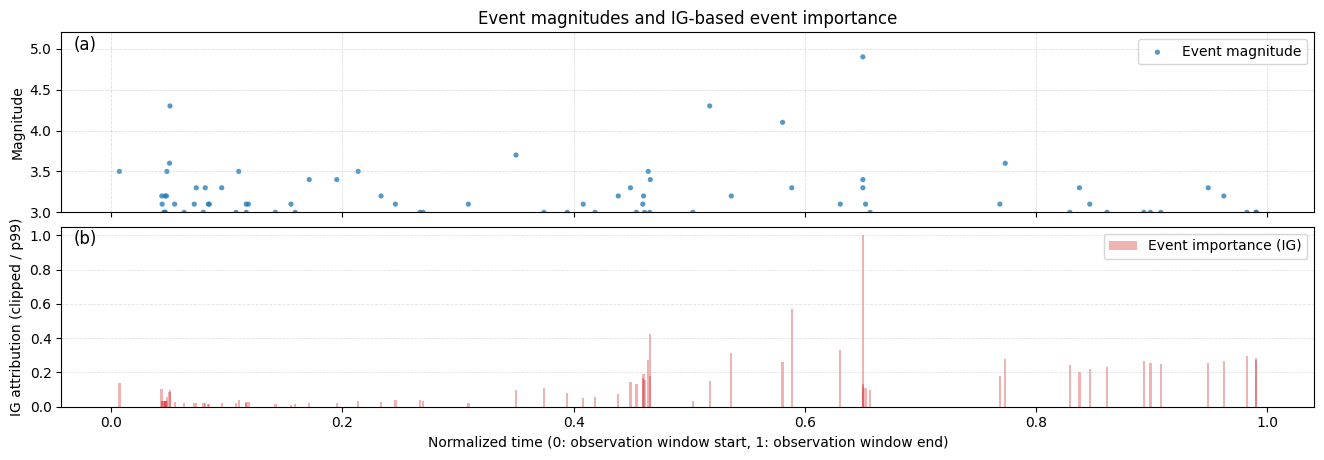

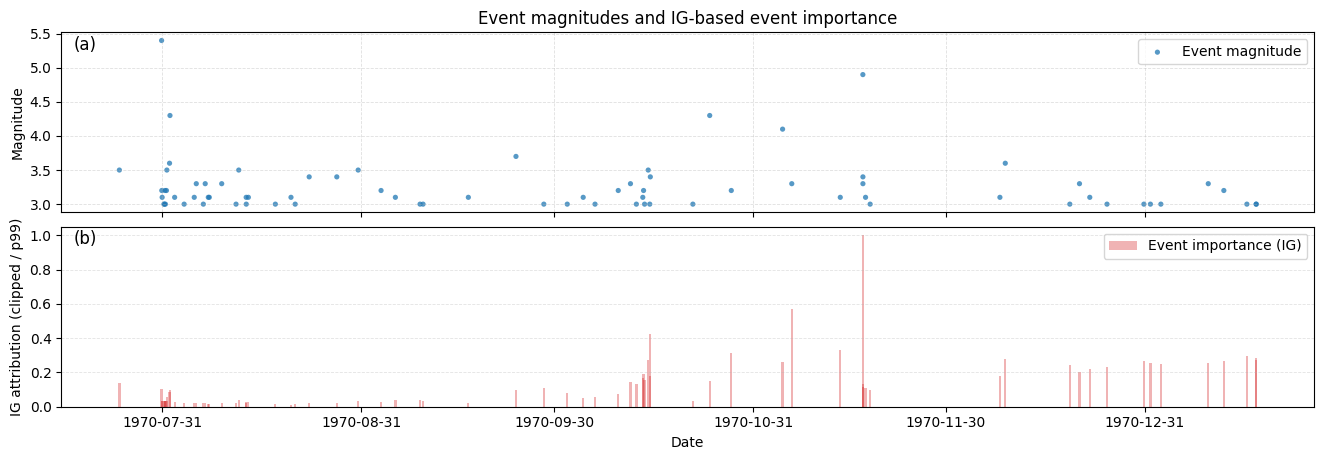

(<Figure size 1400x480 with 2 Axes>,
 <Axes: title={'center': 'Event magnitudes and IG-based event importance'}, ylabel='Magnitude'>,
 <Axes: xlabel='Date', ylabel='IG attribution (clipped / p99)'>)

In [7]:
IG_STEPS = 300
SAMPLE_IDX = 14

x_ig = next(iter(data_loader))[0].to(DEVICE)
scores, labels = interp.compute_token_importance(
    model,
    x_ig,
    method='ig',
    n_steps=IG_STEPS,
    signed=False,
)

mask_np = get_non_pad_mask(x_ig[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=1,
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp_nl.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
    panel_labels=('(a)', '(b)'),
)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=0,
    x_axis='time',
    start_time=t0_np,
    time_scale=1.0,
    time_unit='D',
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
    xlabel='Date',
    clip_mag =None,
    panel_labels=('(a)', '(b)'),
)

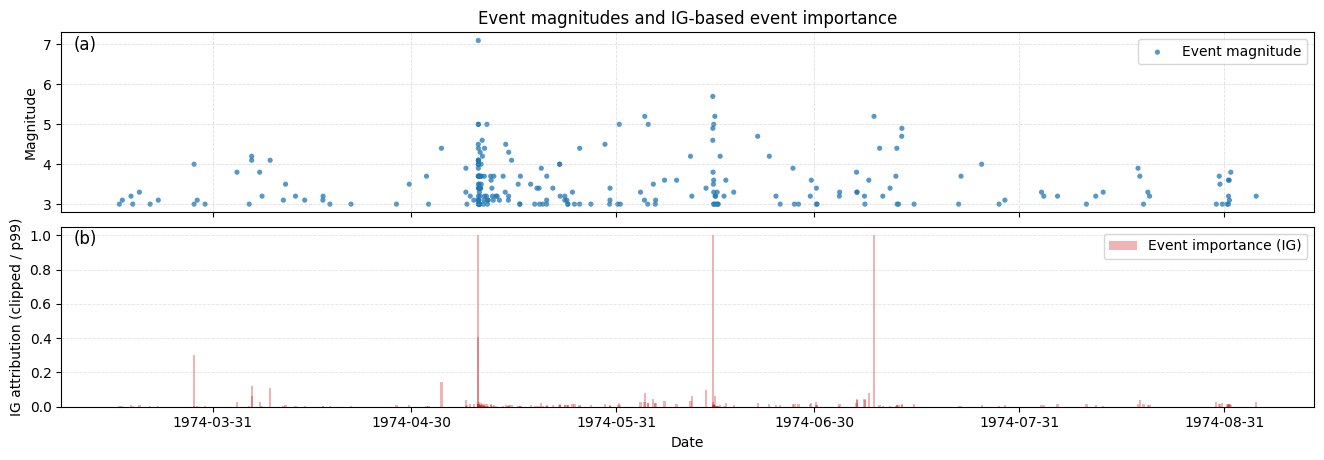

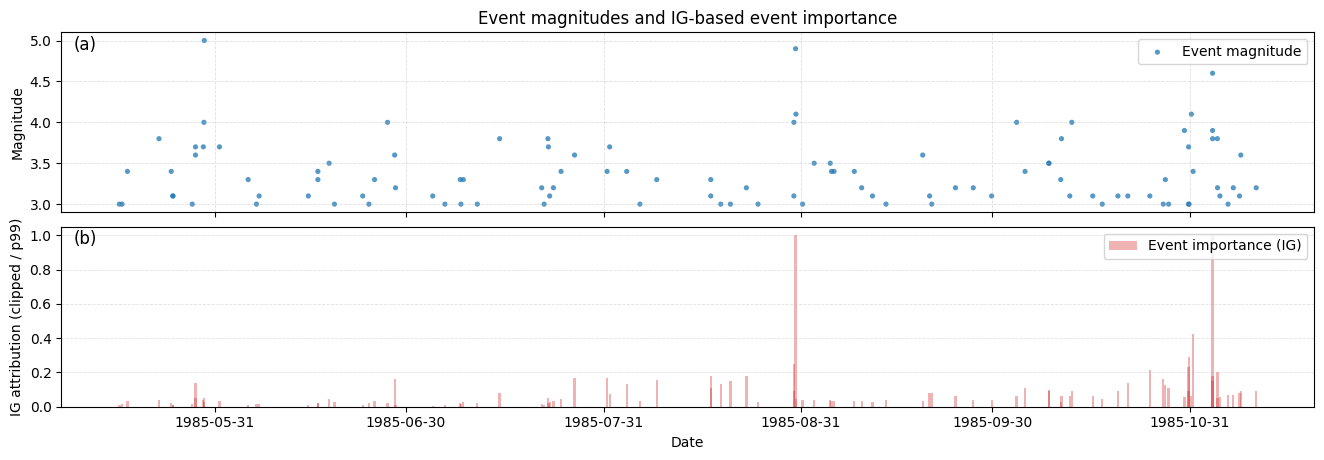

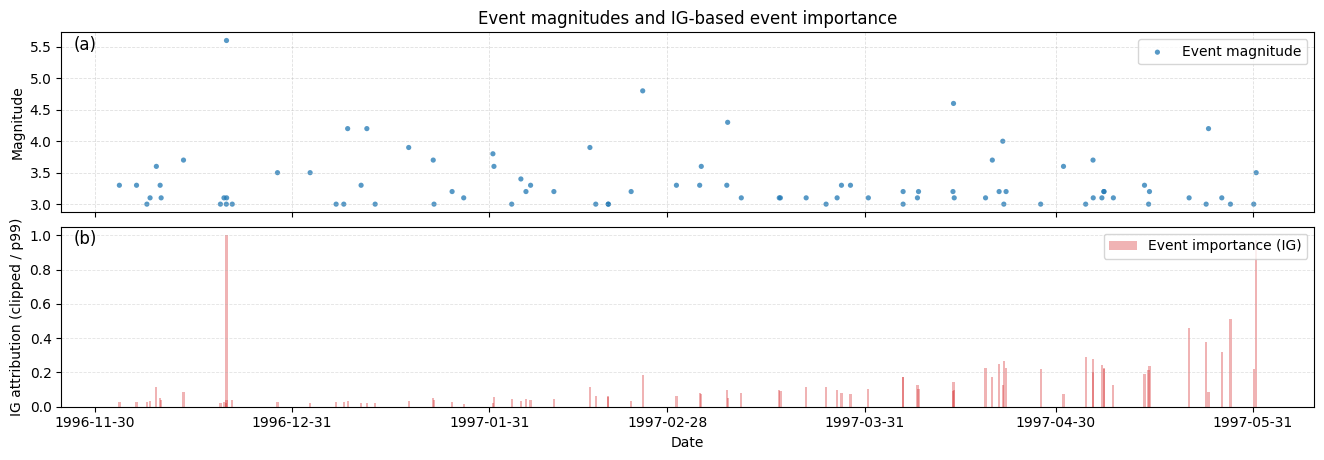

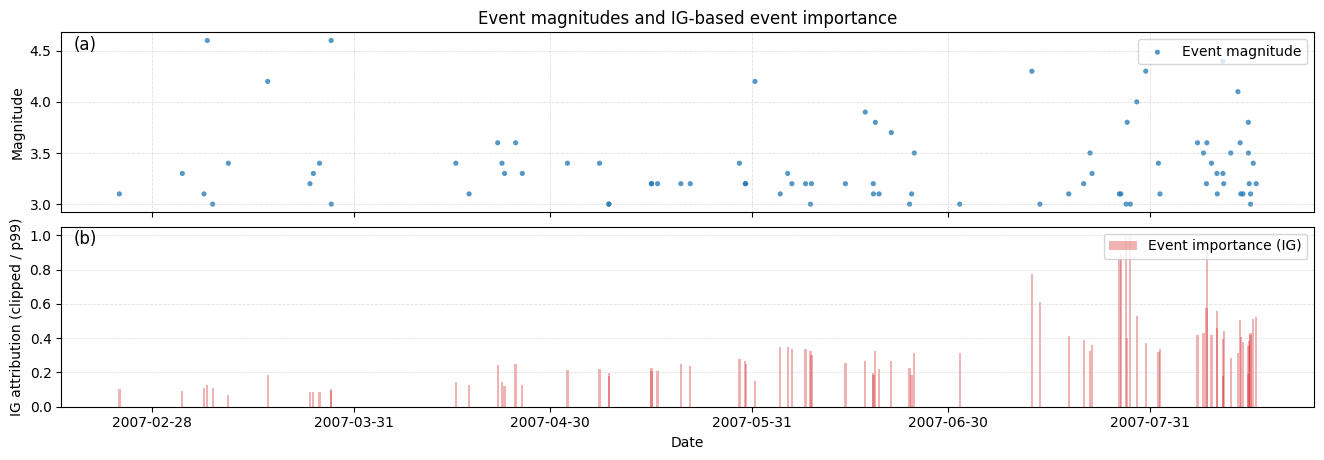

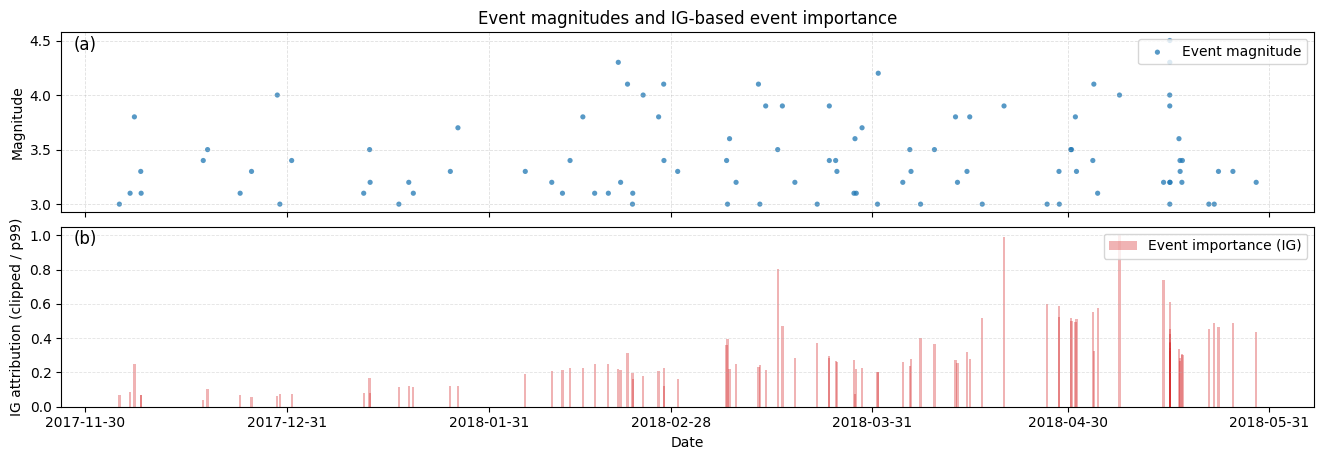

In [8]:
def batch_export_interpretability(
    model,
    data_loader,
    out_dir: Path,
    start_time,
    every_n: int = 10,
    match_mod: int = 3,
    ig_steps: int = 200,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for batch_id, (x_batch, y_batch) in enumerate(data_loader):
        if batch_id % every_n != match_mod:
            continue

        sample_idx = np.random.randint(0, x_batch.shape[0])
        scores, _ = interp.compute_token_importance(
            model,
            x_batch,
            method='ig',
            n_steps=ig_steps,
            signed=False,
        )
        mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

        savepath = out_dir / f'clf_interp_{batch_id}_{sample_idx}.pdf'
        interp.plot_event_magnitude_and_importance_clean(
            x_batch,
            scores,
            batch_idx=sample_idx,
            time_channel=0,
            x_axis='time',
            start_time=start_time,
            time_scale=1.0,
            time_unit='D',
            mag_channel=2,
            importance_norm='p99',
            savepath=str(savepath),
            mag_color='tab:blue',
            imp_color='tab:red',
            mask=mask,
            height_ratios=(2, 2),
            xlabel='Date',
            clip_mag=None,
            panel_labels=('(a)', '(b)'),
        )

set_seed(0)
batch_export_interpretability(
    model=model,
    data_loader=data_loader,
    out_dir=FIG_BATCH_DIR,
    start_time=t0_np,
    every_n=10,
    match_mod=3,
    ig_steps=200,
)